## Importaciones de librerías

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Carga de datos

In [83]:
PATH = '../output/global_activity_clients.csv'
df = pd.read_csv(PATH)
df.head()

,Title,Description,release_year,rating,Category,rental_date,return_date,amount,payment_date,Full Name,City,Country,rental_duration
0,blanket beverly,a emotional documentary of a student and a gir...,2006,G,family,2005-05-24 22:53:30,2005-05-26 22:04:30,2.99,2005-05-24 22:53:30,charlotte hunter,águas lindas de goiás,brazil,2
1,freaky pocus,a fast-paced documentary of a pastry chef and ...,2006,R,music,2005-05-24 22:54:33,2005-05-28 19:40:33,2.99,2005-05-24 22:54:33,tommy collazo,qomsheh,iran,4
2,graduate lord,a lacklusture epistle of a girl and a a shark ...,2006,G,children,2005-05-24 23:03:39,2005-06-01 22:12:39,3.99,2005-05-24 23:03:39,manuel murrell,jaffna,sri lanka,8
3,love suicides,a brilliant panorama of a hunter and a explore...,2006,R,horror,2005-05-24 23:04:41,2005-06-03 01:43:41,4.99,2005-05-24 23:04:41,andrew purdy,baku,azerbaijan,10
4,idols snatchers,a insightful drama of a car and a composer who...,2006,NC-17,children,2005-05-24 23:05:21,2005-06-02 04:33:21,6.99,2005-05-24 23:05:21,delores hansen,jaroslavl,russian federation,9


## Exploración rápida del dataset

In [ ]:
print(f'El dataset tiene {df.shape[0]} filas.')
print(f'El dataset tiene {df.shape[1]} columnas.')

El dataset tiene 15861 filas.
EL dataset tiene 13 columnas.


In [85]:
print(f'El dataset tiene {df.duplicated().sum()} duplicados.')

El dataset tiene 0 duplicados.


In [86]:
print(f'El dataset tiene {df.isnull().sum().sum()} valores nulos.')
print('Valores nulos por columna:')
df.isnull().sum()

El dataset tiene 0 valores nulos.
Valores nulos por columna:


Title              0
Description        0
release_year       0
rating             0
Category           0
rental_date        0
return_date        0
amount             0
payment_date       0
Full Name          0
City               0
Country            0
rental_duration    0
dtype: int64

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            15861 non-null  object 
 1   Description      15861 non-null  object 
 2   release_year     15861 non-null  int64  
 3   rating           15861 non-null  object 
 4   Category         15861 non-null  object 
 5   rental_date      15861 non-null  object 
 6   return_date      15861 non-null  object 
 7   amount           15861 non-null  float64
 8   payment_date     15861 non-null  object 
 9   Full Name        15861 non-null  object 
 10  City             15861 non-null  object 
 11  Country          15861 non-null  object 
 12  rental_duration  15861 non-null  int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 1.6+ MB


In [88]:
print('Exploración rápida de medidas estadísticas de varibles numéricas:')
df.describe()

Exploración rápida de medidas estadísticas de varibles numéricas:


,release_year,amount,rental_duration
count,15861.0,15861.000000,15861.000000
mean,2006.0,4.217161,5.025219
std,0.0,2.360383,2.611835
min,2006.0,0.990000,0.000000
25%,2006.0,2.990000,3.000000
50%,2006.0,3.990000,5.000000
75%,2006.0,4.990000,7.000000
max,2006.0,11.990000,10.000000


In [89]:
print('Exploración rápida de medidas estadísticas de variables categóricas:')
df.describe(include='object')

Exploración rápida de medidas estadísticas de variables categóricas:


,Title,Description,rating,Category,rental_date,return_date,payment_date,Full Name,City,Country
count,15861,15861,15861,15861,15861,15861,15861,15861,15861,15861
unique,958,958,5,16,15813,15836,15813,599,597,108
top,bucket brotherhood,a amazing display of a girl and a womanizer wh...,PG-13,sports,2005-07-27 15:18:42,2005-07-10 04:54:26,2005-07-27 15:18:42,eleanor hunt,aurora,india
freq,34,34,3543,1164,2,2,2,46,48,1548


Al realizar esta exploración podemos ver que el dataset no presenta duplicados, valores nulos y los diferentes tipos de columnas y sus tipos.
También podemos presenciar que las variables que poseen información de fecha están en formato texto y que la variable `release_year` es el mismo en todos los registros, por lo que no aporta información y tendríamos que proceder a elimnarla en futuros pasos.

## Normalización

In [90]:
# Copia del dataset para limpieza y análisis
df_clean = df.copy()

He detectado que los nombres de las columnas, algunos están en mayúsculas y otros en minúsculas y las que están formados por dos palabras presentan un `_` como separación y `Full Name` no lo posee, por lo que vamos a proceder a normalizarlo

In [91]:
df_clean.columns = df_clean.columns.str.lower().str.strip().str.replace(' ', '_')

In [92]:
# Normalización a tipo fecha
date_columns = ['rental_date', 'return_date', 'payment_date']
for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col])

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   title            15861 non-null  object        
 1   description      15861 non-null  object        
 2   release_year     15861 non-null  int64         
 3   rating           15861 non-null  object        
 4   category         15861 non-null  object        
 5   rental_date      15861 non-null  datetime64[ns]
 6   return_date      15861 non-null  datetime64[ns]
 7   amount           15861 non-null  float64       
 8   payment_date     15861 non-null  datetime64[ns]
 9   full_name        15861 non-null  object        
 10  city             15861 non-null  object        
 11  country          15861 non-null  object        
 12  rental_duration  15861 non-null  int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(7)
memory usage: 1.6+ MB


## Creación de columnas adicionales y borrado de las columnas que no aporten valor

In [93]:
# Creación de columnas adicionales a partir de las fechas
df_clean['rental_day'] = df_clean['rental_date'].dt.day
df_clean['rental_month'] = df_clean['rental_date'].dt.month
df_clean['rental_year'] = df_clean['rental_date'].dt.year
df_clean['rental_hour'] = df_clean['rental_date'].dt.hour
df_clean['return_day'] = df_clean['return_date'].dt.day
df_clean['return_month'] = df_clean['return_date'].dt.month
df_clean['return_year'] = df_clean['return_date'].dt.year
df_clean['return_hour'] = df_clean['return_date'].dt.hour

# Creación de la columna 'day_of_week_rental' para indicar el día de la semana en el que se realizó el alquiler
df_clean['day_of_week_rental'] = df_clean['rental_date'].dt.dayofweek + 1

# Creación de columna 'is_weekend_rental' para indicar si el alquiler se realizó en fin de semana (1) o no (0)
df_clean['is_weekend_rental'] = df_clean['day_of_week_rental'].apply(lambda x: 1 if x in [6, 7] else 0)

# Creación de la columna 'season' para indicar la estación del año en el que se realizó el alquiler
df_clean['season'] = df_clean['rental_month'].apply(lambda x: 'spring' if x in [3,4,5] else ('summer' if x in [6,7,8] else ('autumn' if x in [9,10,11] else 'winter')))

# Creación de la columna 'part_of_the_day' para indicar el tramo del día en el que se realizó el alquiler
df_clean['rental_hour_part_of_the_day'] = df_clean['rental_hour'].apply(lambda x: 'night' if x in [0,1,2,3,4,5,6] else('morning' if x in [7,8,9,10,11,12] else 'afternoon'))

# Creación de la columna 'part_of_the_day' para indicar el tramo del día en el que se realizó la devolución
df_clean['return_hour_part_of_the_day'] = df_clean['return_hour'].apply(lambda x: 'night' if x in [0,1,2,3,4,5,6] else('morning' if x in [7,8,9,10,11,12] else 'afternoon'))

# Creación de la columna 'payment_lag' para indicar el tiempo transcurrido entre la fecha de alquiler y la fecha de pago. Lo ideal es que sea 0,
# pero puede haber casos en los que el pago se realice después del alquiler. Sirve para detectar posibles anomalías
df_clean['payment_lag'] = df_clean['payment_date'].dt.day - df_clean['rental_date'].dt.day

# Creación de la columna 'film_age' para indicar la antigüedad de la película desde su año de lanzamiento.
df_clean['film_age'] = dt.datetime.now().year - df_clean['release_year']

# Creación de la columna 'is_adult_content' para indicar si la película es para adultos o no, basándonos en su clasificación por edades
df_clean['is_adult_content'] = df_clean['rating'].apply(lambda x: 1 if x in ['R', 'NC-17'] else 0)

In [94]:
# Borrado de la columna release_year por ser irrelevante para el análisis
df_clean = df_clean.drop(columns=['release_year', 'rental_date', 'return_date'], axis=1)

In [95]:
df_clean.head()

,title,description,rating,category,amount,payment_date,full_name,city,country,rental_duration,...,return_year,return_hour,day_of_week_rental,is_weekend_rental,season,rental_hour_part_of_the_day,return_hour_part_of_the_day,payment_lag,film_age,is_adult_content
0,blanket beverly,a emotional documentary of a student and a gir...,G,family,2.99,2005-05-24 22:53:30,charlotte hunter,águas lindas de goiás,brazil,2,...,2005,22,2,0,spring,afternoon,afternoon,0,20,0
1,freaky pocus,a fast-paced documentary of a pastry chef and ...,R,music,2.99,2005-05-24 22:54:33,tommy collazo,qomsheh,iran,4,...,2005,19,2,0,spring,afternoon,afternoon,0,20,1
2,graduate lord,a lacklusture epistle of a girl and a a shark ...,G,children,3.99,2005-05-24 23:03:39,manuel murrell,jaffna,sri lanka,8,...,2005,22,2,0,spring,afternoon,afternoon,0,20,0
3,love suicides,a brilliant panorama of a hunter and a explore...,R,horror,4.99,2005-05-24 23:04:41,andrew purdy,baku,azerbaijan,10,...,2005,1,2,0,spring,afternoon,night,0,20,1
4,idols snatchers,a insightful drama of a car and a composer who...,NC-17,children,6.99,2005-05-24 23:05:21,delores hansen,jaroslavl,russian federation,9,...,2005,4,2,0,spring,afternoon,night,0,20,1


## Tratamiento de valores Nulos y Outliers

In [96]:
# Comprobación adicional de valores nulos tras la creación de nuevas columnas
df_clean.isnull().sum()

title                          0
description                    0
rating                         0
category                       0
amount                         0
payment_date                   0
full_name                      0
city                           0
country                        0
rental_duration                0
rental_day                     0
rental_month                   0
rental_year                    0
rental_hour                    0
return_day                     0
return_month                   0
return_year                    0
return_hour                    0
day_of_week_rental             0
is_weekend_rental              0
season                         0
rental_hour_part_of_the_day    0
return_hour_part_of_the_day    0
payment_lag                    0
film_age                       0
is_adult_content               0
dtype: int64

En este caso, en el dataset no contiene valores nulos, por lo que no tenemos que realizar ningún tipo de tratamiento.

In [101]:
for col in df_clean.columns:
    print(f'Columna: {col} - Tipo de dato: {df_clean[col].dtype}')

Columna: title - Tipo de dato: object
Columna: description - Tipo de dato: object
Columna: rating - Tipo de dato: object
Columna: category - Tipo de dato: object
Columna: amount - Tipo de dato: float64
Columna: payment_date - Tipo de dato: datetime64[ns]
Columna: full_name - Tipo de dato: object
Columna: city - Tipo de dato: object
Columna: country - Tipo de dato: object
Columna: rental_duration - Tipo de dato: int64
Columna: rental_day - Tipo de dato: int32
Columna: rental_month - Tipo de dato: int32
Columna: rental_year - Tipo de dato: int32
Columna: rental_hour - Tipo de dato: int32
Columna: return_day - Tipo de dato: int32
Columna: return_month - Tipo de dato: int32
Columna: return_year - Tipo de dato: int32
Columna: return_hour - Tipo de dato: int32
Columna: day_of_week_rental - Tipo de dato: int32
Columna: is_weekend_rental - Tipo de dato: int64
Columna: season - Tipo de dato: object
Columna: rental_hour_part_of_the_day - Tipo de dato: object
Columna: return_hour_part_of_the_day 

In [110]:
variables_numericas = []
variables_categoricas = []

variables_a_ignorar = ['title', 'description', 'full_name', 'city', 'country','payment_date', 'rental_day', 'rental_month', 'rental_year', 'rental_hour', 'return_day', 'return_month', 'return_year', 'return_hour']

for col in df_clean.columns:
    if col in variables_a_ignorar:
        continue
    elif df_clean[col].dtype in ['int64', 'float64', 'int32']:
        variables_numericas.append(col)
    else:
        variables_categoricas.append(col)
print(f'Variables numéricas a analizar: {variables_numericas}')
print(f'Variables categóricas a analizar: {variables_categoricas}')

Variables numéricas a analizar: ['amount', 'rental_duration', 'day_of_week_rental', 'is_weekend_rental', 'payment_lag', 'film_age', 'is_adult_content']
Variables categóricas a analizar: ['rating', 'category', 'season', 'rental_hour_part_of_the_day', 'return_hour_part_of_the_day']


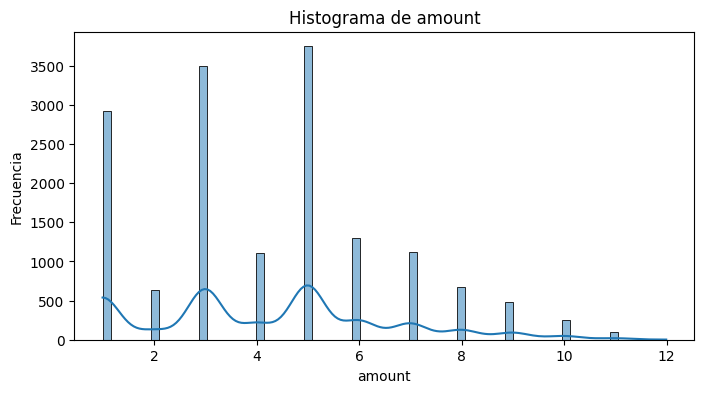

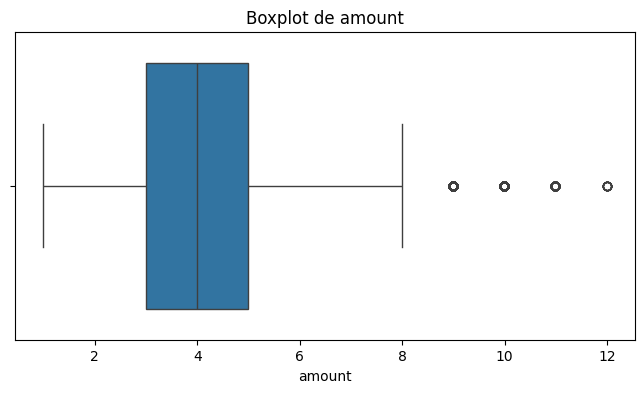

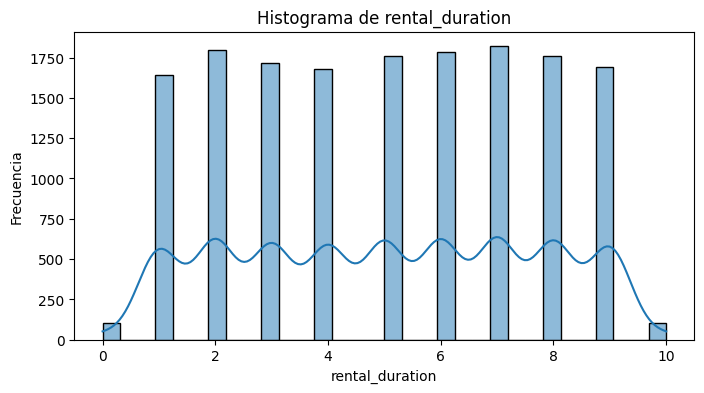

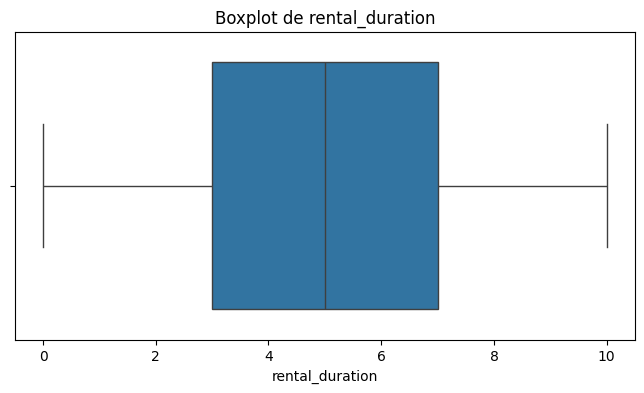

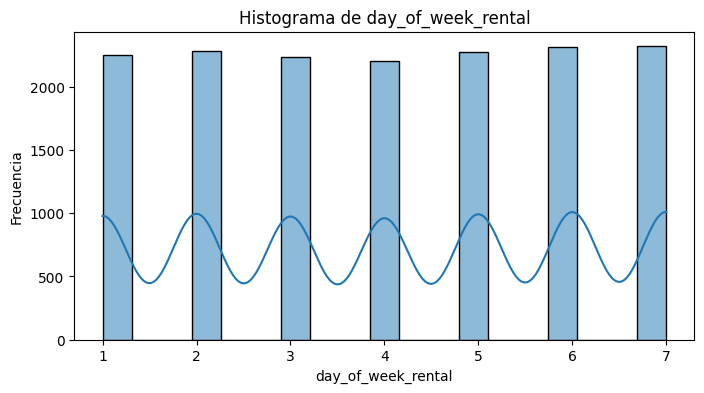

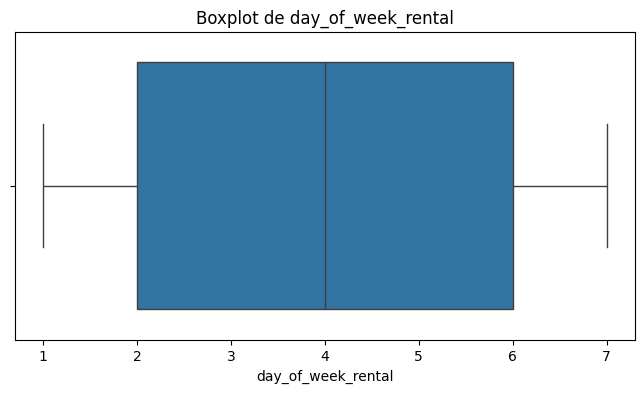

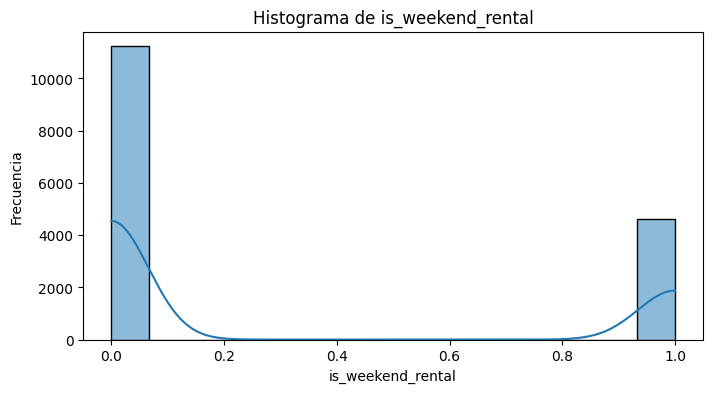

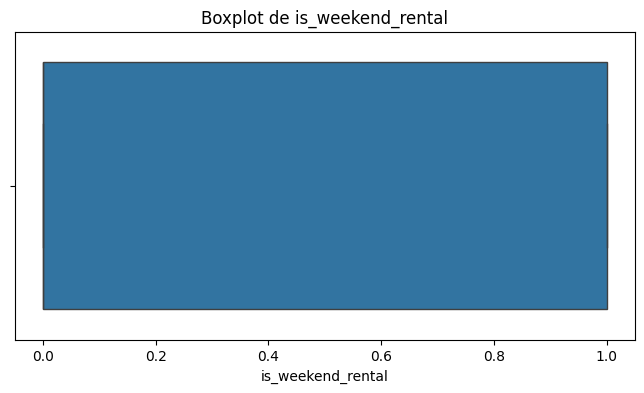

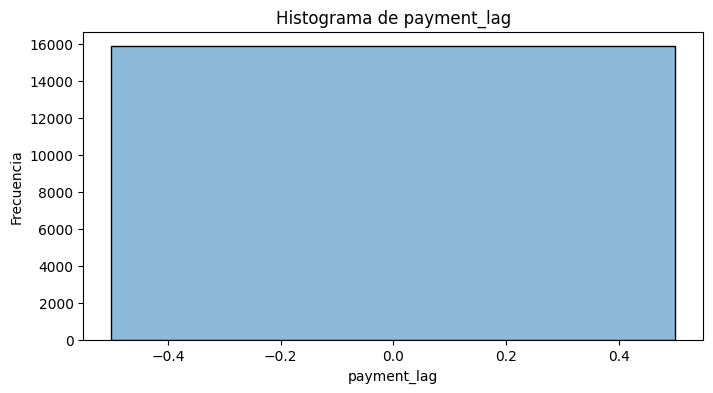

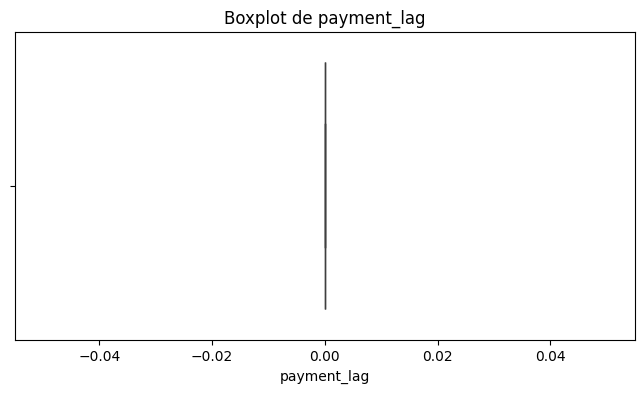

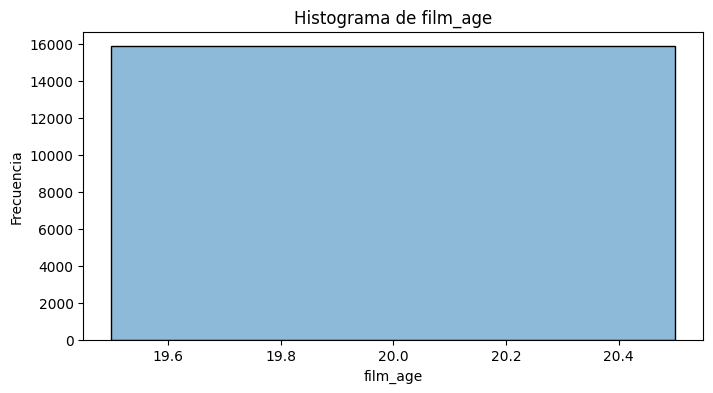

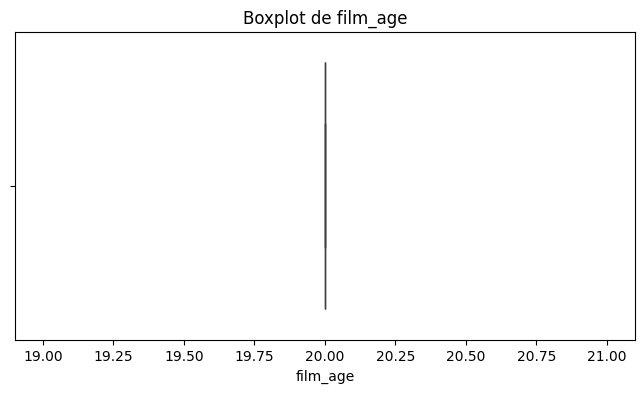

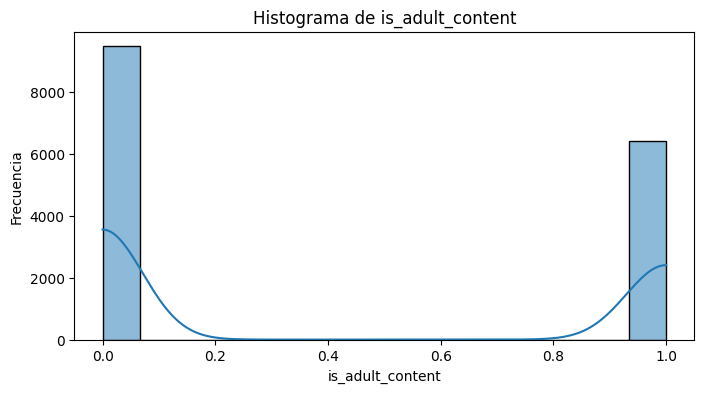

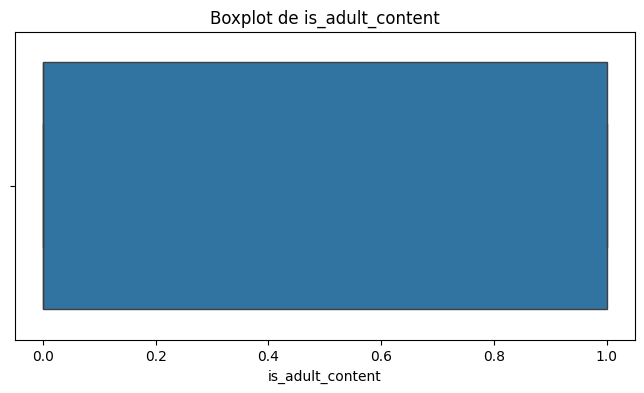

In [111]:
for col in variables_numericas:
    plt.figure(figsize=(8,4))
    sns.histplot(df_clean[col], kde=True)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_clean[col], orient='horizontal')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

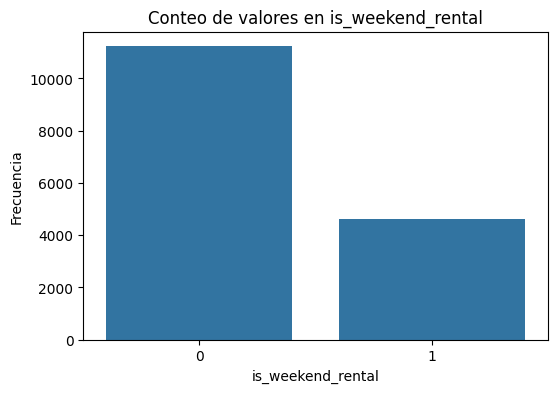

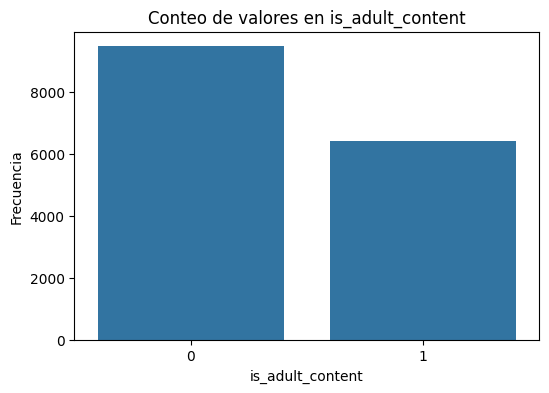

In [112]:
# Las columnas que sólo contiene valores 0-1, es mejor analizarlo con un countplot para ver la distribución de cada valor
columnas_0_1 = ['is_weekend_rental', 'is_adult_content']

for col in columnas_0_1:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df_clean[col])
    plt.title(f'Conteo de valores en {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_5608\952809480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean[col], order=df_clean[col].value_counts().index, palette='viridis', orient='vertical')


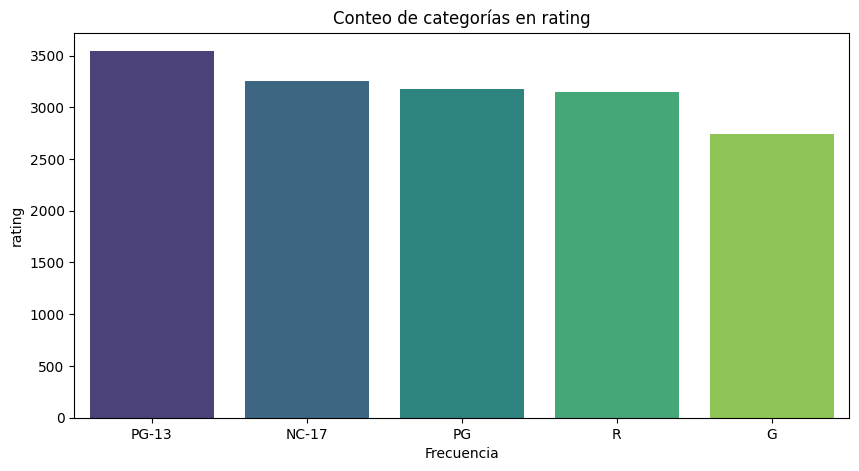

C:\Users\danie\AppData\Local\Temp\ipykernel_5608\952809480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean[col], order=df_clean[col].value_counts().index, palette='viridis', orient='vertical')


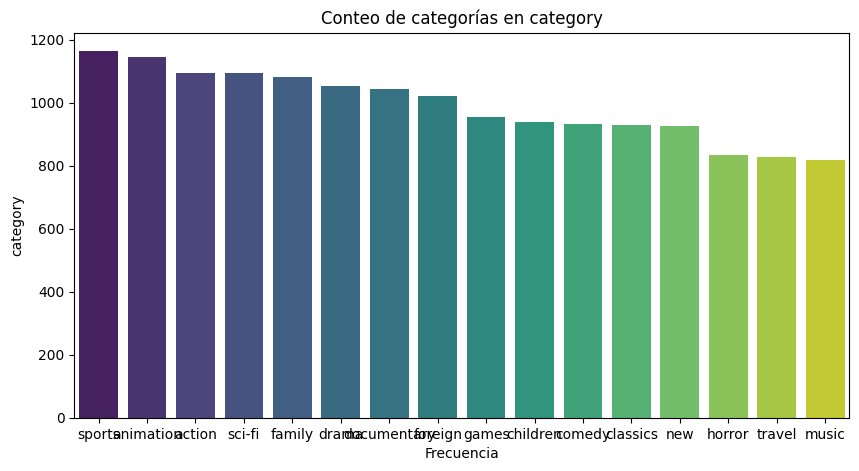

C:\Users\danie\AppData\Local\Temp\ipykernel_5608\952809480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean[col], order=df_clean[col].value_counts().index, palette='viridis', orient='vertical')


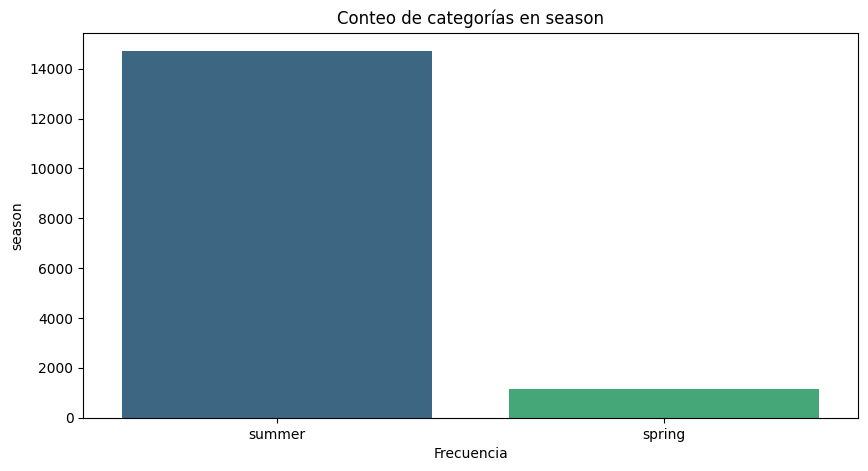

C:\Users\danie\AppData\Local\Temp\ipykernel_5608\952809480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean[col], order=df_clean[col].value_counts().index, palette='viridis', orient='vertical')


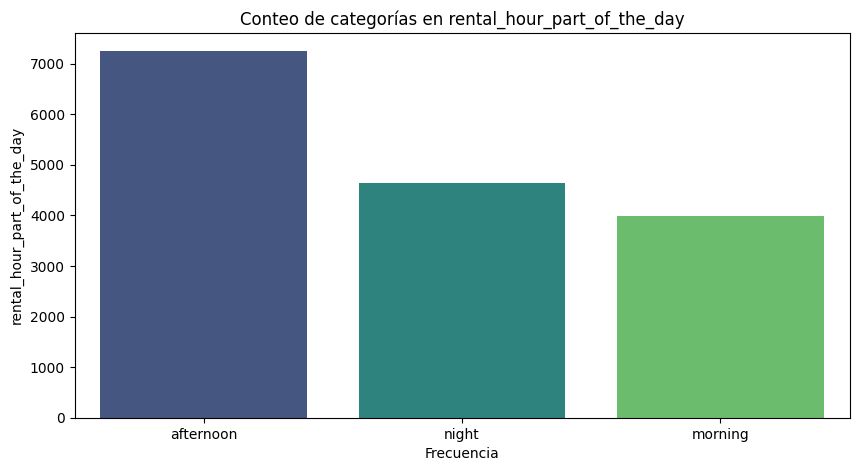

C:\Users\danie\AppData\Local\Temp\ipykernel_5608\952809480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean[col], order=df_clean[col].value_counts().index, palette='viridis', orient='vertical')


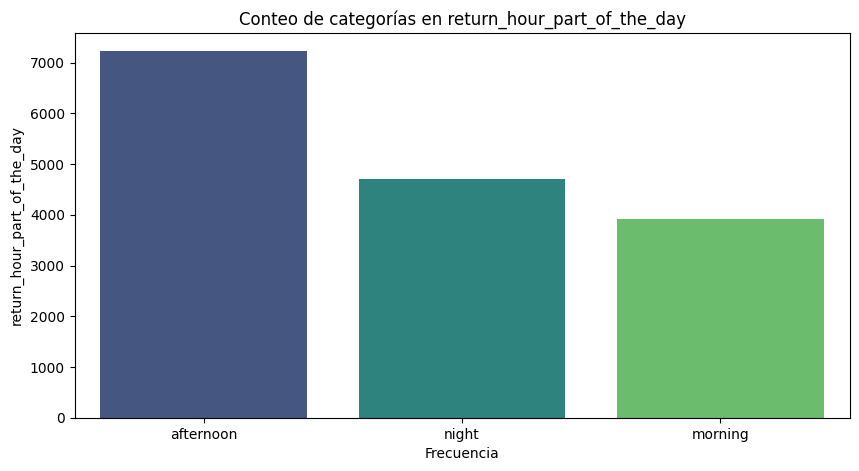

In [ ]:
for col in variables_categoricas:
    plt.figure(figsize=(10,5))
    sns.countplot(x=df_clean[col], order=df_clean[col].value_counts().index, palette='viridis')
    plt.title(f'Conteo de categorías en {col}')
    plt.xlabel('Frecuencia')
    plt.ylabel(col)
    plt.show()

En este caso, solamente poseemos valores outliers en la columna amount, pero al tratarse de solamente 4 valores hemos decidido no realizar ningún tratamiento.

## Dashboard

### Películas más alquiladas

C:\Users\danie\AppData\Local\Temp\ipykernel_5608\1130683806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['title'], order=df_clean['title'].value_counts().index[:10], palette='magma')


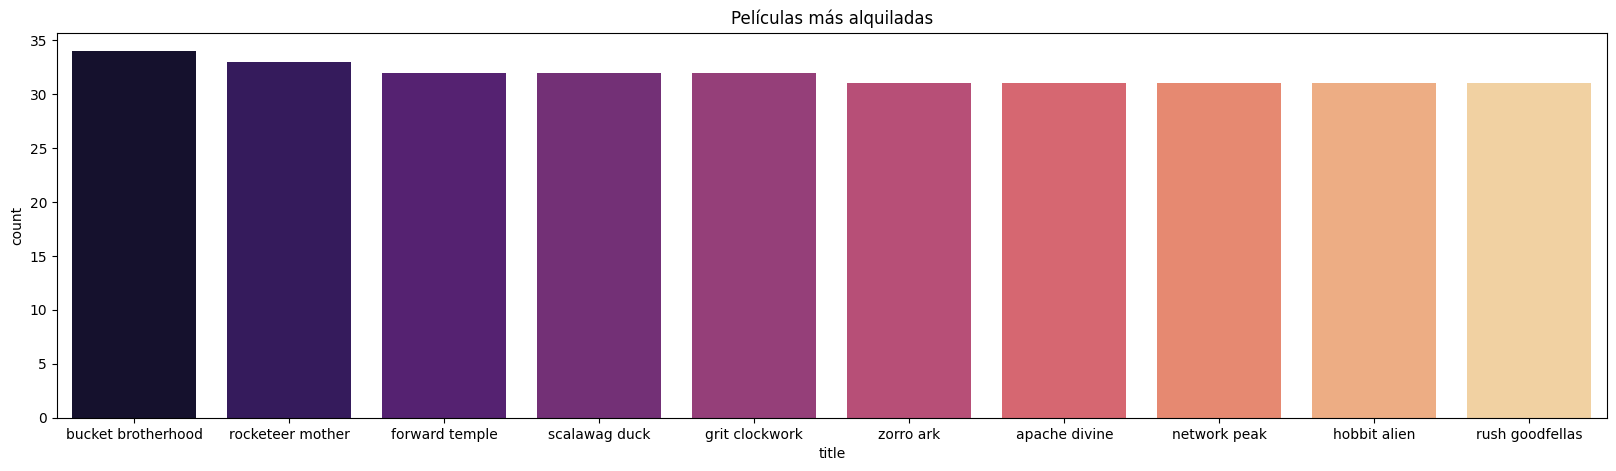

In [123]:
plt.figure(figsize=(20,5))
sns.countplot(x=df_clean['title'], order=df_clean['title'].value_counts().index[:10], palette='magma')
plt.title('Películas más alquiladas')
plt.show()

### Películas con más ingresos de alquiler

C:\Users\danie\AppData\Local\Temp\ipykernel_5608\2378948449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_clean['title'],order=df_clean['amount'].groupby(df_clean['title']).sum().sort_values(ascending=False).index[:10], palette='magma')


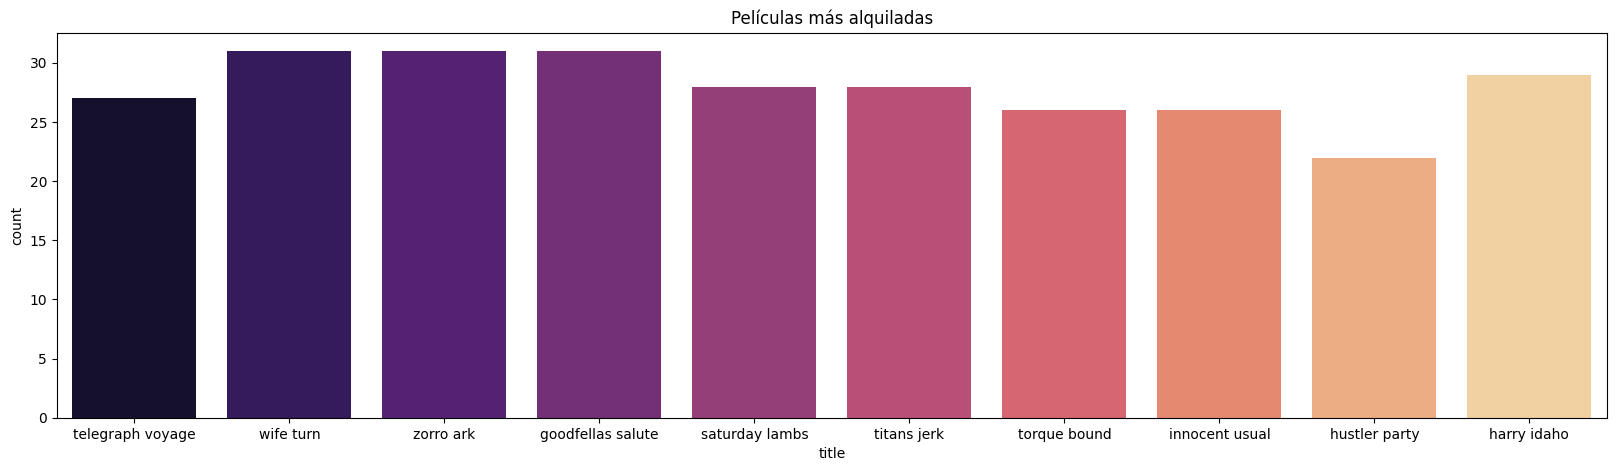

In [125]:
plt.figure(figsize=(20,5))
sns.countplot(x=df_clean['title'],order=df_clean['amount'].groupby(df_clean['title']).sum().sort_values(ascending=False).index[:10], palette='magma')
plt.title('Películas más alquiladas')
plt.show()

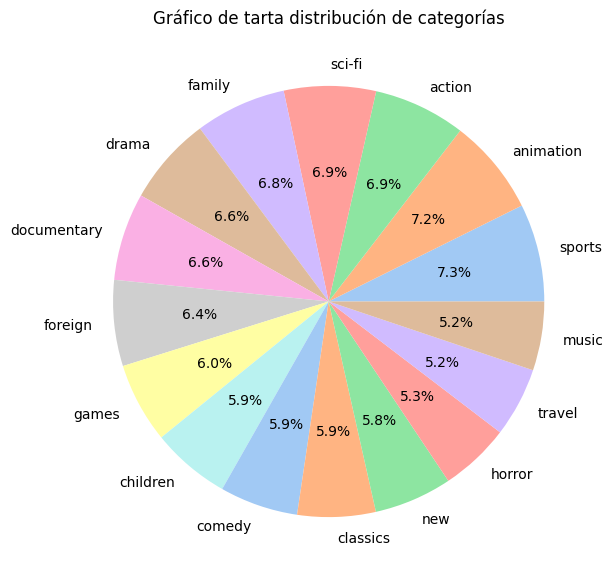

In [127]:
plt.figure(figsize=(7,7))
plt.pie(df_clean['category'].value_counts(), labels=df_clean['category'].value_counts().index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Gráfico de tarta distribución de categorías')
plt.show()

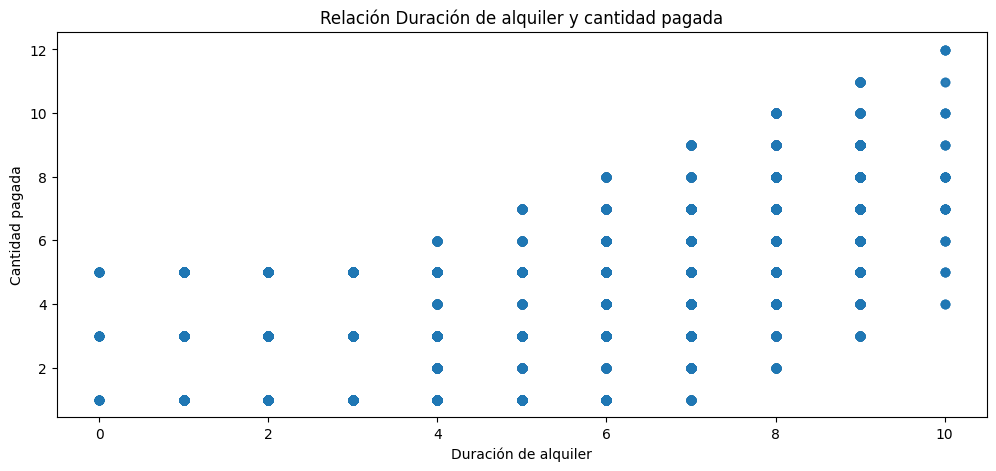

In [129]:
plt.figure(figsize=(12,5))
plt.scatter(df_clean['rental_duration'], df_clean['amount'], alpha=0.5)
plt.title('Relación Duración de alquiler y cantidad pagada')
plt.xlabel('Duración de alquiler')
plt.ylabel('Cantidad pagada')
plt.show()

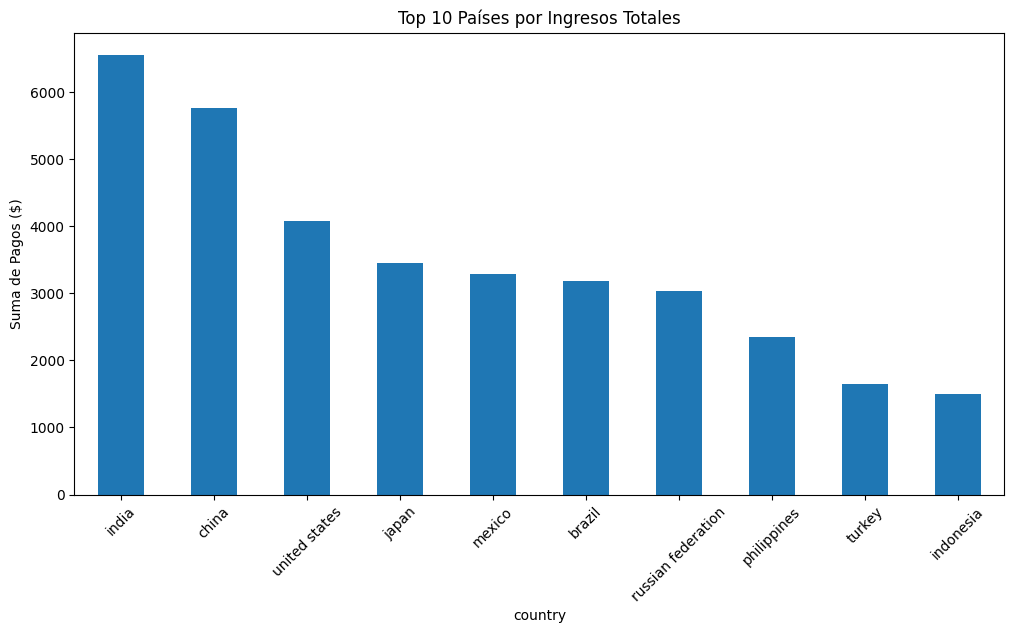

In [132]:
top_countries = df_clean.groupby('country')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_countries.plot(kind='bar')
plt.title('Top 10 Países por Ingresos Totales')
plt.ylabel('Suma de Pagos ($)')
plt.xticks(rotation=45)
plt.show()

In [133]:
df_clean.to_csv('../output/global-activity-clients-tratado.csv', index=False)